Samantha Asefi (sma9am@virginia.edu)
DS 5001
8 May 2026

# Sentiment Analysis

## imports

In [1]:
OHCO  = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
CHAPS = OHCO[:2]
SENTS = OHCO[:4]

nrc_cols = 'nrc_negative nrc_positive nrc_anger nrc_anticipation nrc_disgust nrc_fear nrc_joy nrc_sadness nrc_surprise nrc_trust'.split()
emo_cols  = 'anger anticipation disgust fear joy sadness surprise trust polarity'.split()
emo = 'polarity'

AUTHOR_MAP = {
    'luxemburg_reform-or-revolution':          'Rosa Luxemburg',
    'mao_on-guerrilla-warfare':                'Mao Zedong',
    'mao_correcting-mistaken-ideas':           'Mao Zedong',
    'mao_tactics-against-japanese-imperialism':'Mao Zedong',
    'mao_on-practice':                         'Mao Zedong',
    'mao_win-the-masses':                      'Mao Zedong',
    'marx_communist-manifesto':                'Karl Marx & Friedrich Engels',
    'marx_wage-labour-and-capital':            'Karl Marx',
    'fourier_selections':                      'Charles Fourier'
}

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set()
%matplotlib inline

f2_dir = Path('corpus/f2')
f5_dir = Path('corpus/f5')
f5_dir.mkdir(parents=True, exist_ok=True)


## Data Load

In [3]:
TOKEN = pd.read_csv(f2_dir / 'TOKEN.csv').set_index(OHCO).sort_index()
VOCAB = pd.read_csv('corpus/f4/VOCAB.csv', index_col='term_str')

print('TOKEN shape:', TOKEN.shape)
TOKEN.head()


TOKEN shape: (437101, 5)


pos_tuple  \
book_id            chap_num para_num sent_num token_num                            
fourier_selections 1        3        0        2          ('philosophical', 'JJ')   
                                              3                 ('whims', 'NNS')   
                                              4                ('called', 'VBN')   
                                              5                ('duties', 'NNS')   
                                              8               ('relation', 'NN')   

                                                             token_str  pos  \
book_id            chap_num para_num sent_num token_num                       
fourier_selections 1        3        0        2          philosophical   JJ   
                                              3                  whims  NNS   
                                              4                 called  VBN   
                                              5                 duties  NNS   
                                              8               relation   NN   

                                                              term_str  \
book_id            chap_num para_num sent_num token_num                  
fourier_selections 1        3        0        2          philosophical   
                                              3                  whims   
                                              4                 called   
                                              5                 duties   
                                              8               relation   

                                                         is_stop  
book_id            chap_num para_num sent_num token_num           
fourier_selections 1        3        0        2            False  
                                              3            False  
                                              4            False  
                                              5            False  
                                              8            False

## Get Lexicon

In [4]:
salex = pd.read_csv('salex_nrc.csv').set_index('term_str')
salex.columns = [col.replace('nrc_', '') for col in salex.columns]
salex['polarity'] = salex.positive - salex.negative


In [5]:
salex['polarity'] = salex.positive - salex.negative


## Get Lexicon Columns

In [6]:
emo_cols = "anger anticipation disgust fear joy sadness surprise trust polarity".split()
emo_cols

['anger',
 'anticipation',
 'disgust',
 'fear',
 'joy',
 'sadness',
 'surprise',
 'trust',
 'polarity']

## Adding Lexicon to Tokens

In [7]:
TOKEN = TOKEN.join(salex, on='term_str', how='left')
TOKEN[emo_cols] = TOKEN[emo_cols].fillna(0)

# Add author label
TOKEN['author'] = TOKEN.index.get_level_values('book_id').map(AUTHOR_MAP)

TOKEN[['term_str'] + emo_cols].sample(10)

term_str  \
book_id                                  chap_num para_num sent_num token_num                 
marx_wage-labour-and-capital             3        8        3        7                   low   
mao_win-the-masses                       1        7        103      36               united   
mao_tactics-against-japanese-imperialism 1        16       7        15                comes   
                                                  46       19       21            communist   
                                                  23       160      24                first   
mao_win-the-masses                       1        5        48       4             emphasize   
mao_tactics-against-japanese-imperialism 1        3        354      20            organized   
                                                  16       429      6               chinese   
fourier_selections                       27       16       0        100        accomplished   
mao_tactics-against-japanese-imperialism 1        35       246      71                armed   

                                                                               anger  \
book_id                                  chap_num para_num sent_num token_num          
marx_wage-labour-and-capital             3        8        3        7            0.0   
mao_win-the-masses                       1        7        103      36           0.0   
mao_tactics-against-japanese-imperialism 1        16       7        15           0.0   
                                                  46       19       21           0.0   
                                                  23       160      24           0.0   
mao_win-the-masses                       1        5        48       4            0.0   
mao_tactics-against-japanese-imperialism 1        3        354      20           0.0   
                                                  16       429      6            0.0   
fourier_selections                       27       16       0        100          0.0   
mao_tactics-against-japanese-imperialism 1        35       246      71           1.0   

                                                                               anticipation  \
book_id                                  chap_num para_num sent_num token_num                 
marx_wage-labour-and-capital             3        8        3        7                   0.0   
mao_win-the-masses                       1        7        103      36                  0.0   
mao_tactics-against-japanese-imperialism 1        16       7        15                  0.0   
                                                  46       19       21                  0.0   
                                                  23       160      24                  0.0   
mao_win-the-masses                       1        5        48       4                   0.0   
mao_tactics-against-japanese-imperialism 1        3        354      20                  0.0   
                                                  16       429      6                   0.0   
fourier_selections                       27       16       0        100                 0.0   
mao_tactics-against-japanese-imperialism 1        35       246      71                  0.0   

                                                                               disgust  \
book_id                                  chap_num para_num sent_num token_num            
marx_wage-labour-and-capital             3        8        3        7              0.0   
mao_win-the-masses                       1        7        103      36             0.0   
mao_tactics-against-japanese-imperialism 1        16       7        15             0.0   
                                                  46       19       21             0.0   
                                                  23       160      24             0.0   
mao_win-the-masses                       1        5        48       4              0.0   
mao_tactics-against-japa

## ## Sentiment by Author — Mean Emotion Profile

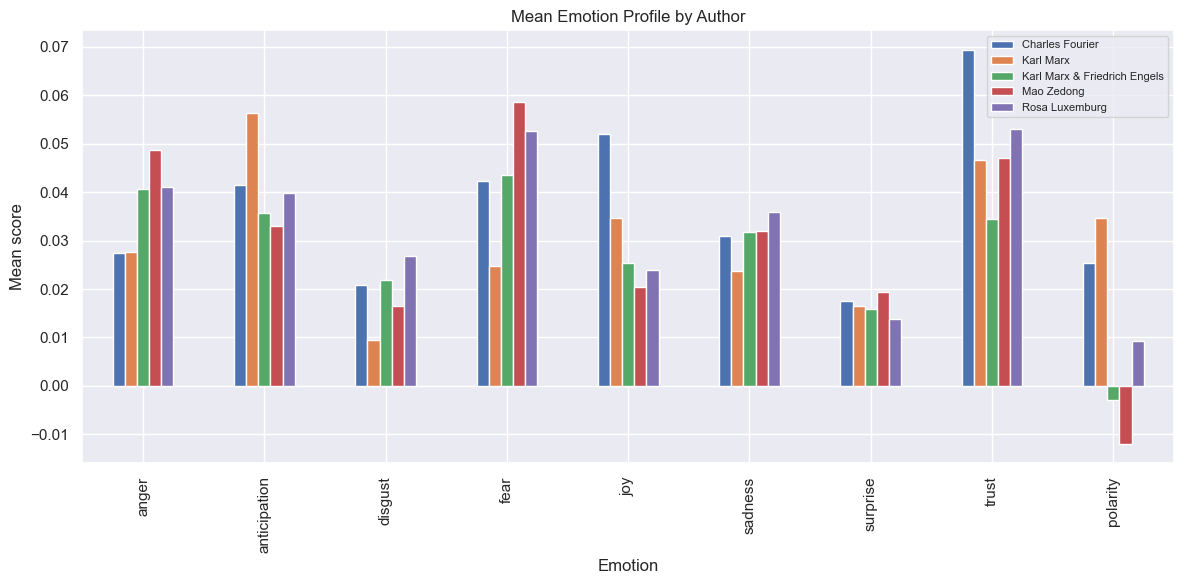

In [8]:
author_emo = TOKEN.groupby('author')[emo_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
author_emo.T.plot(kind='bar', ax=ax)
ax.set_title('Mean Emotion Profile by Author')
ax.set_xlabel('Emotion')
ax.set_ylabel('Mean score')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f5_dir / 'sentiment_author_emotions.png', dpi=150, bbox_inches='tight')
plt.show()


## Sentiment by Chapter

In [9]:
CHAP_SENT = TOKEN.groupby(CHAPS)[emo_cols].mean()
CHAP_SENT['author'] = CHAP_SENT.index.get_level_values('book_id').map(AUTHOR_MAP)
CHAP_SENT = CHAP_SENT.reset_index()

fig = px.scatter(
    CHAP_SENT,
    x='chap_num', y='polarity',
    color='author',
    hover_data=['book_id'],
    title='Sentiment Polarity by Chapter'
)
fig.show()

## Polarity Heatmap - Chapter X Emotion

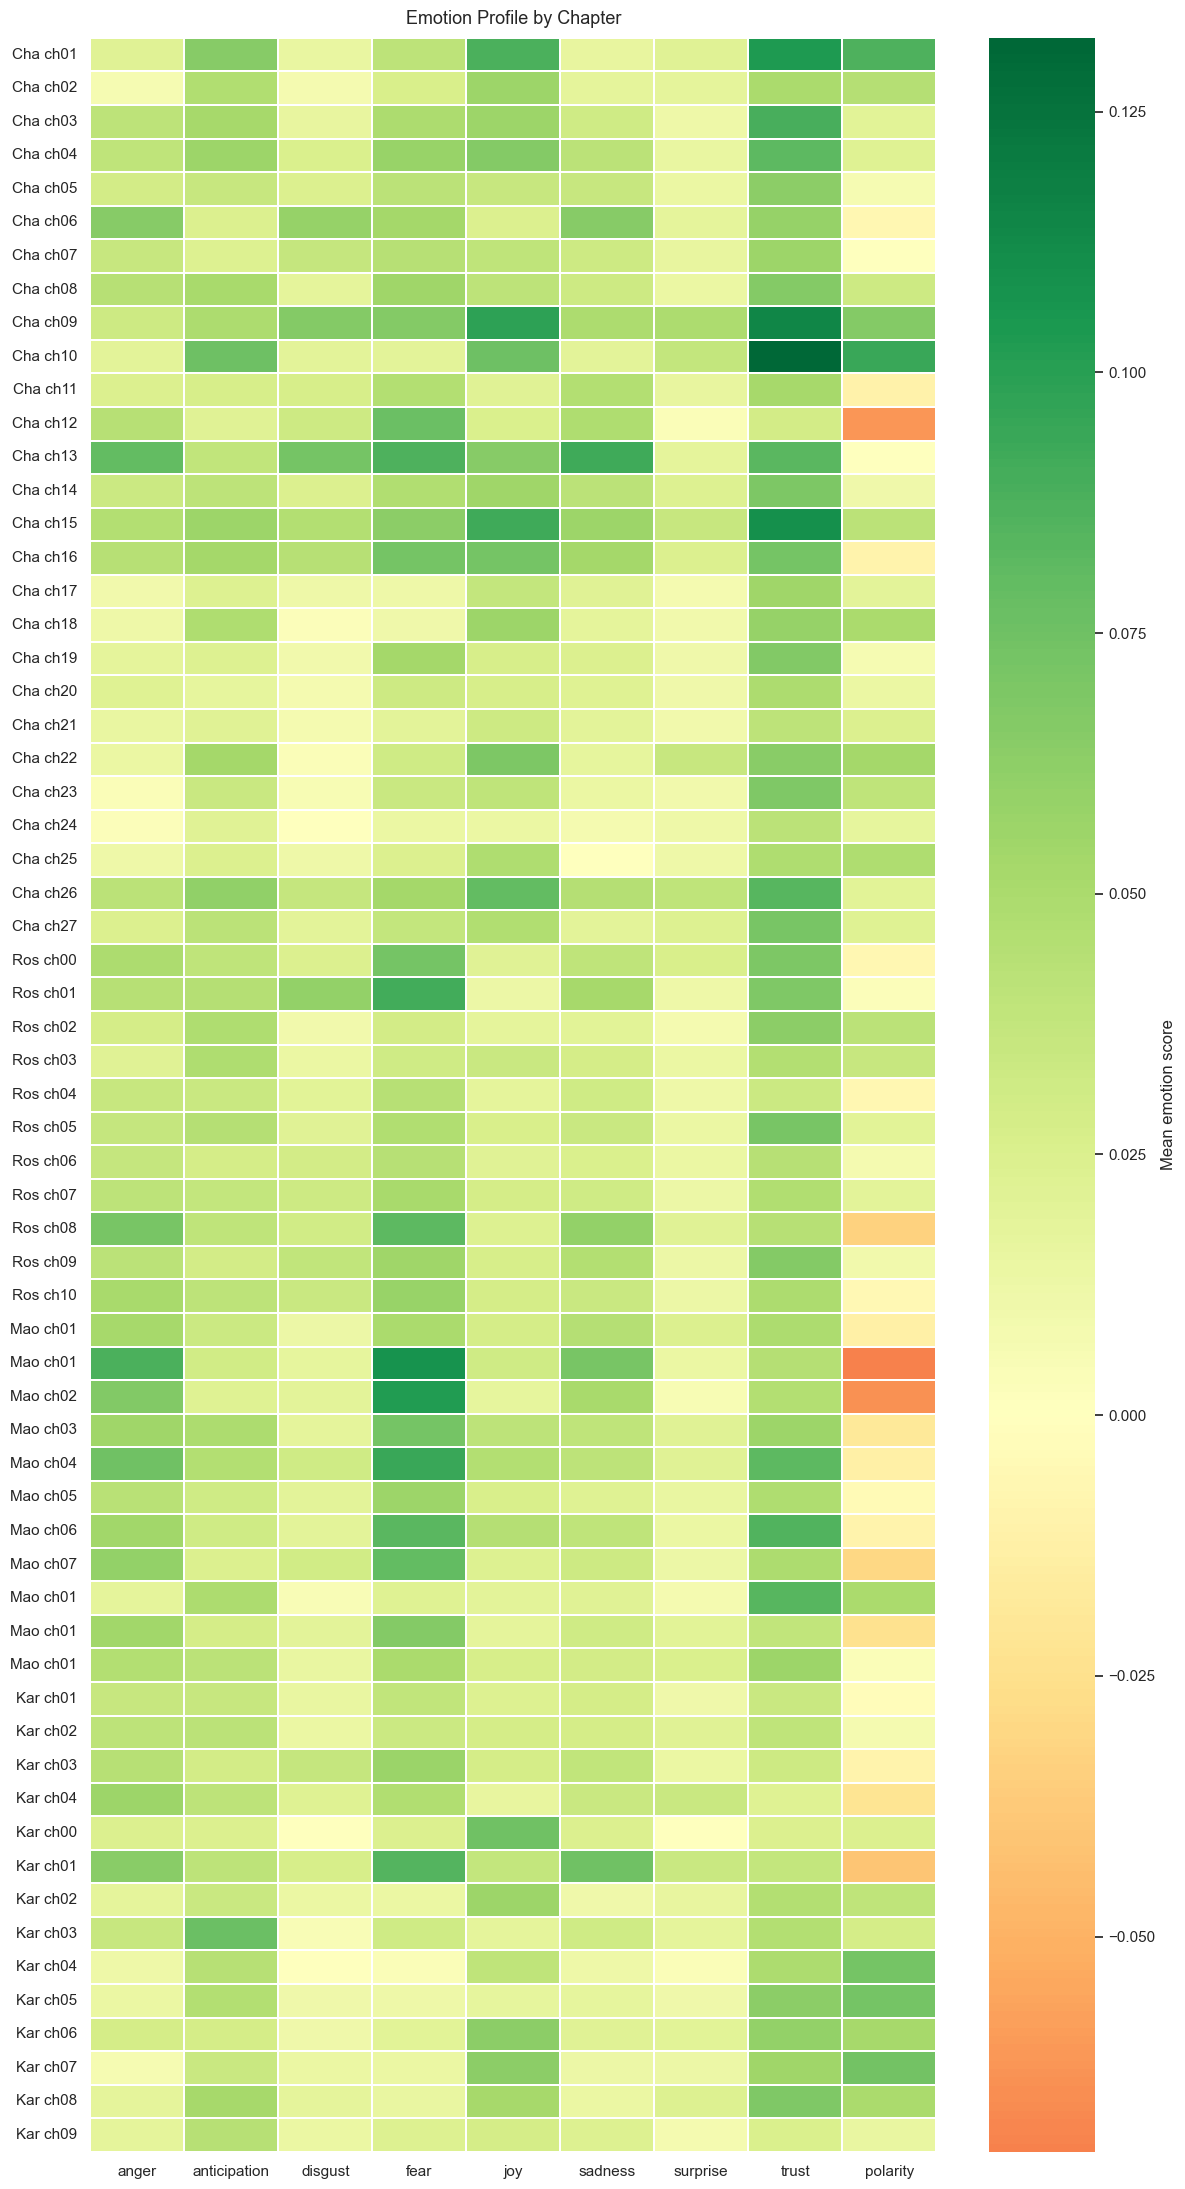

In [10]:
heat_data = TOKEN.groupby(CHAPS)[emo_cols].mean()
heat_data.index = [
    f"{AUTHOR_MAP.get(b, b)[:3]} ch{c:02d}"
    for b, c in heat_data.index
]

fig, ax = plt.subplots(figsize=(12, max(6, len(heat_data) * 0.35)))
sns.heatmap(
    heat_data, cmap='RdYlGn', center=0,
    linewidths=.2, linecolor='white', ax=ax,
    cbar_kws={'label': 'Mean emotion score'}
)
ax.set_title('Emotion Profile by Chapter', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(f5_dir / 'sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## VADER

In [11]:
vader_cols = ['pos', 'neg', 'neu', 'compound']


In [12]:
analyser = SentimentIntensityAnalyzer()

# Reconstruct sentences from tokens
SENT_STR = (
    TOKEN.groupby(SENTS)
    .term_str
    .apply(lambda x: ' '.join(x.dropna().tolist()))
    .to_frame(name='sent_str')
)

# Apply VADER
vader_scores = (
    SENT_STR['sent_str']
    .apply(analyser.polarity_scores)
    .apply(pd.Series)
)

SENT_VADER = pd.concat([SENT_STR, vader_scores], axis=1)
SENT_VADER['author'] = SENT_VADER.index.get_level_values('book_id').map(AUTHOR_MAP)

print('SENT_VADER shape:', SENT_VADER.shape)
SENT_VADER.head()

SENT_VADER shape: (33974, 6)


sent_str  \
book_id            chap_num para_num sent_num                                                      
fourier_selections 1        3        0         philosophical whims called duties relation wha...   
                            4        0         learned world wholly imbued doctrine termed mo...   
                            5        0         morality teaches man war resist passions repre...   
                                     1         imbued prejudices regarding impotence god lear...   
                            6        0         true impulses entice us evil yield individuall...   

                                                 neg    neu    pos  compound  \
book_id            chap_num para_num sent_num                                  
fourier_selections 1        3        0         0.000  0.635  0.365    0.9337   
                            4        0         0.205  0.468  0.327    0.2732   
                            5        0         0.246  0.442  0.312    0.3400   
                                     1         0.109  0.504  0.388    0.7351   
                            6        0         0.106  0.633  0.261    0.7783   

                                                        author  
book_id            chap_num para_num sent_num                   
fourier_selections 1        3        0         Charles Fourier  
                            4        0         Charles Fourier  
                            5        0         Charles Fourier  
                                     1         Charles Fourier  
                            6        0         Charles Fourier

## VADER by Author -- Mean Scores


Charles Fourier


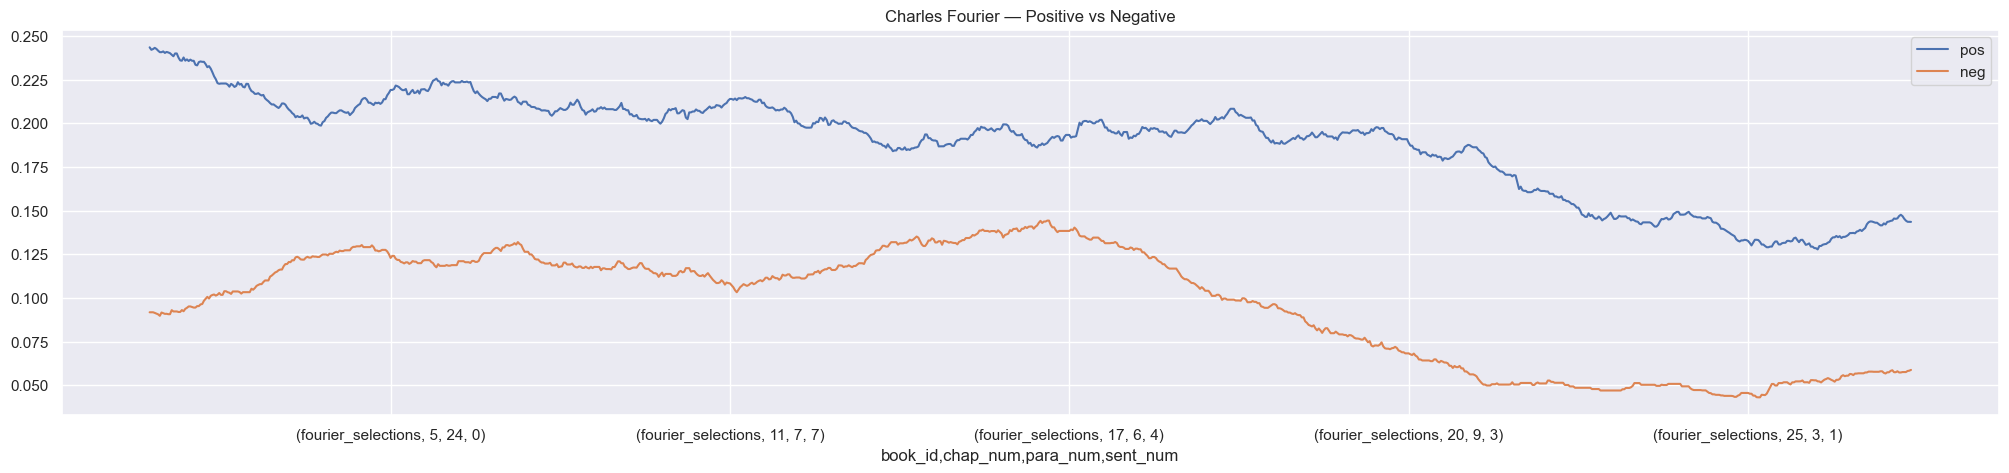

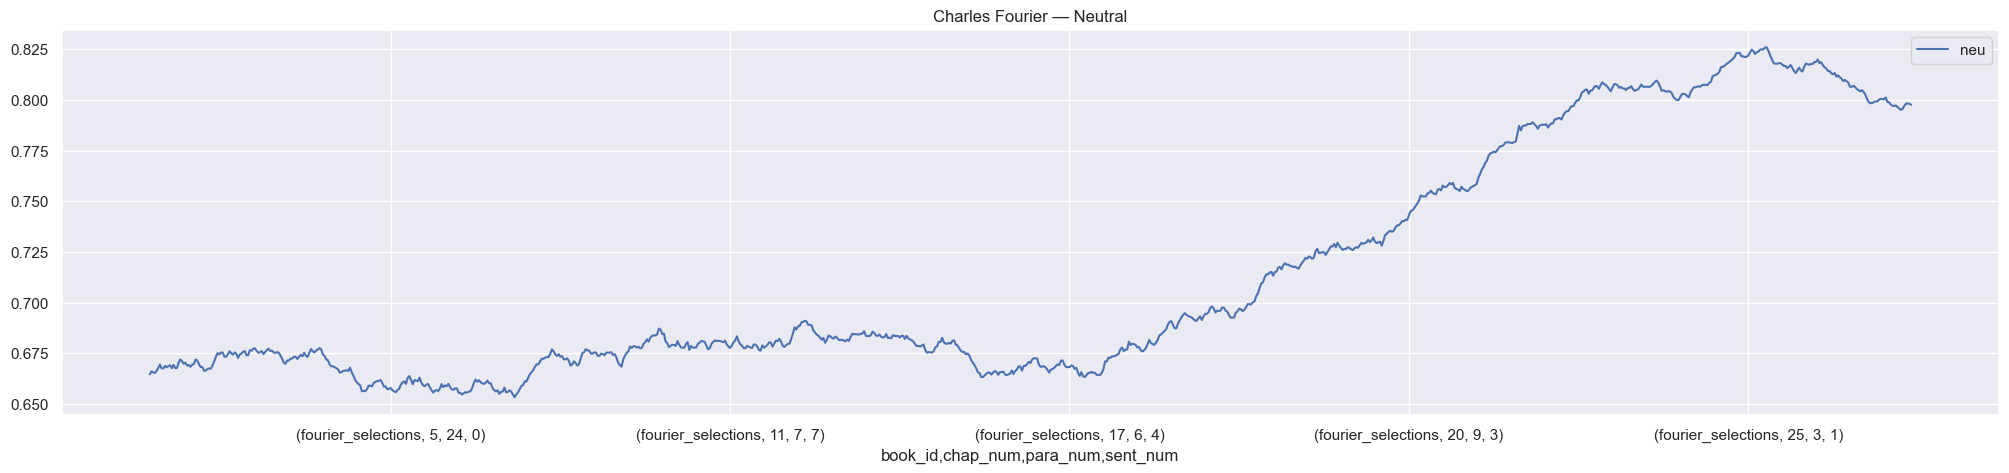

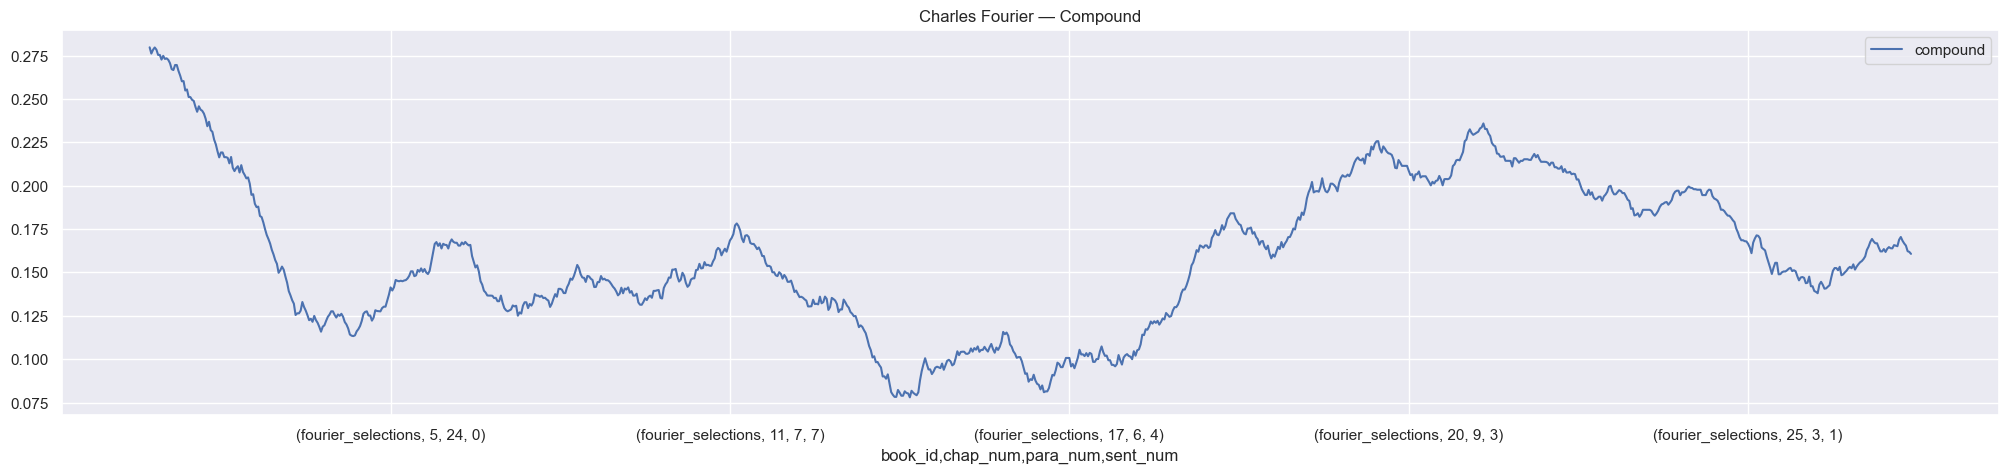


Karl Marx


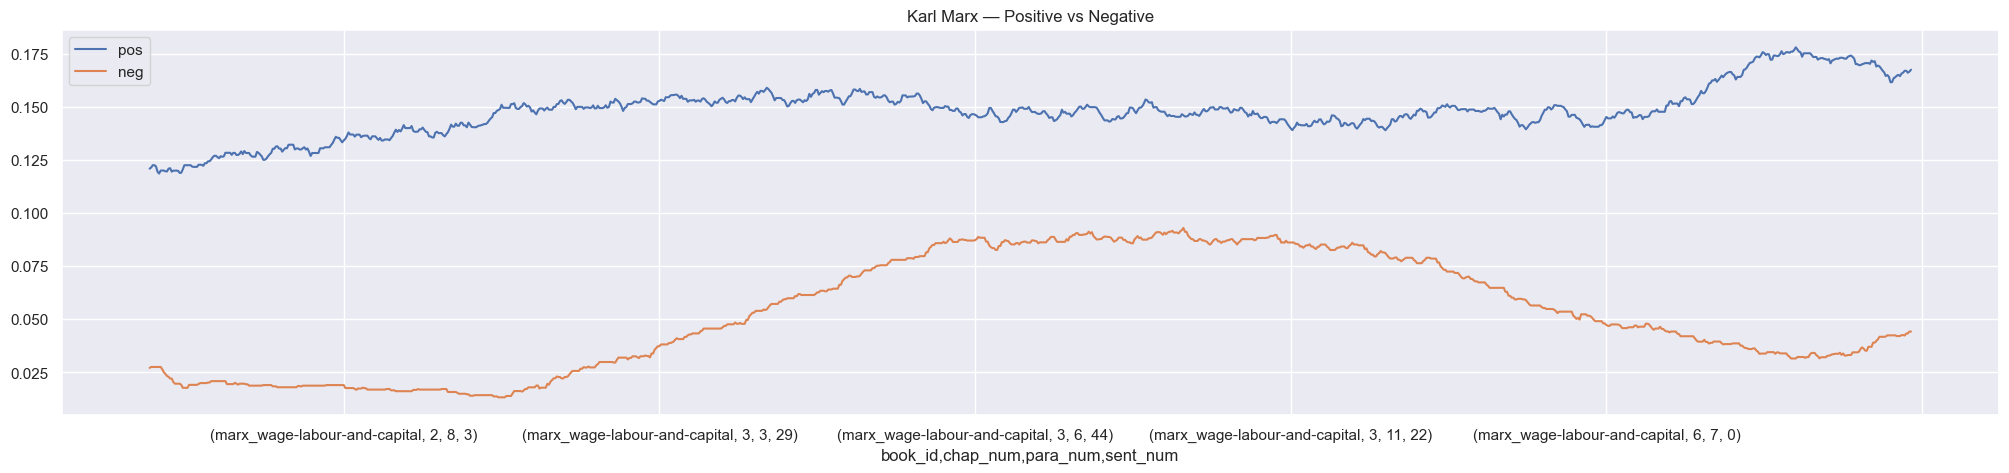

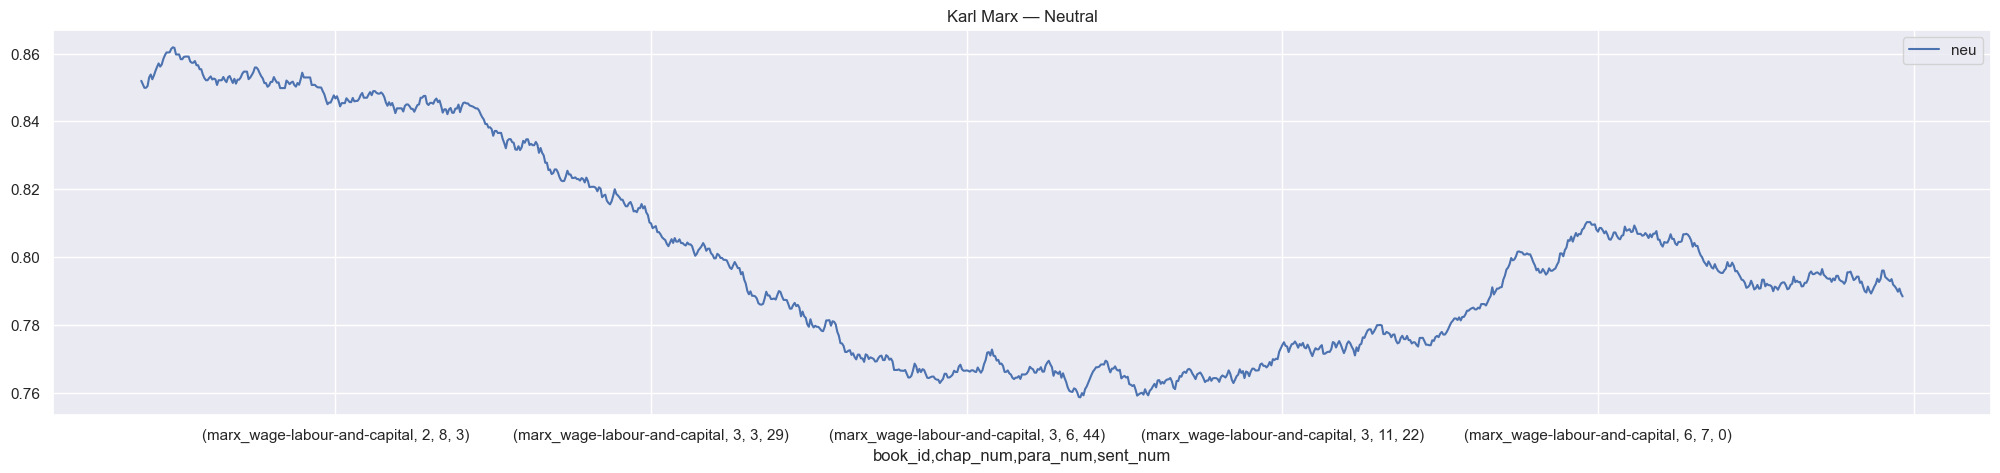

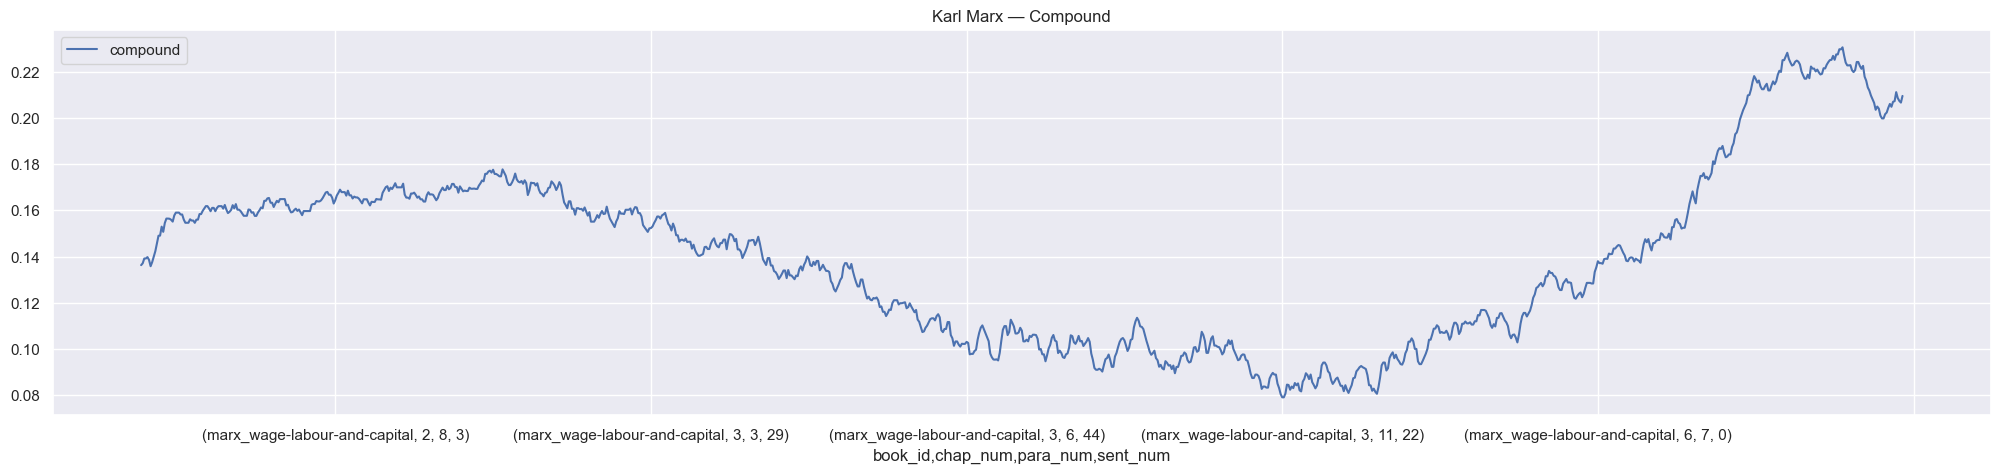


Karl Marx & Friedrich Engels


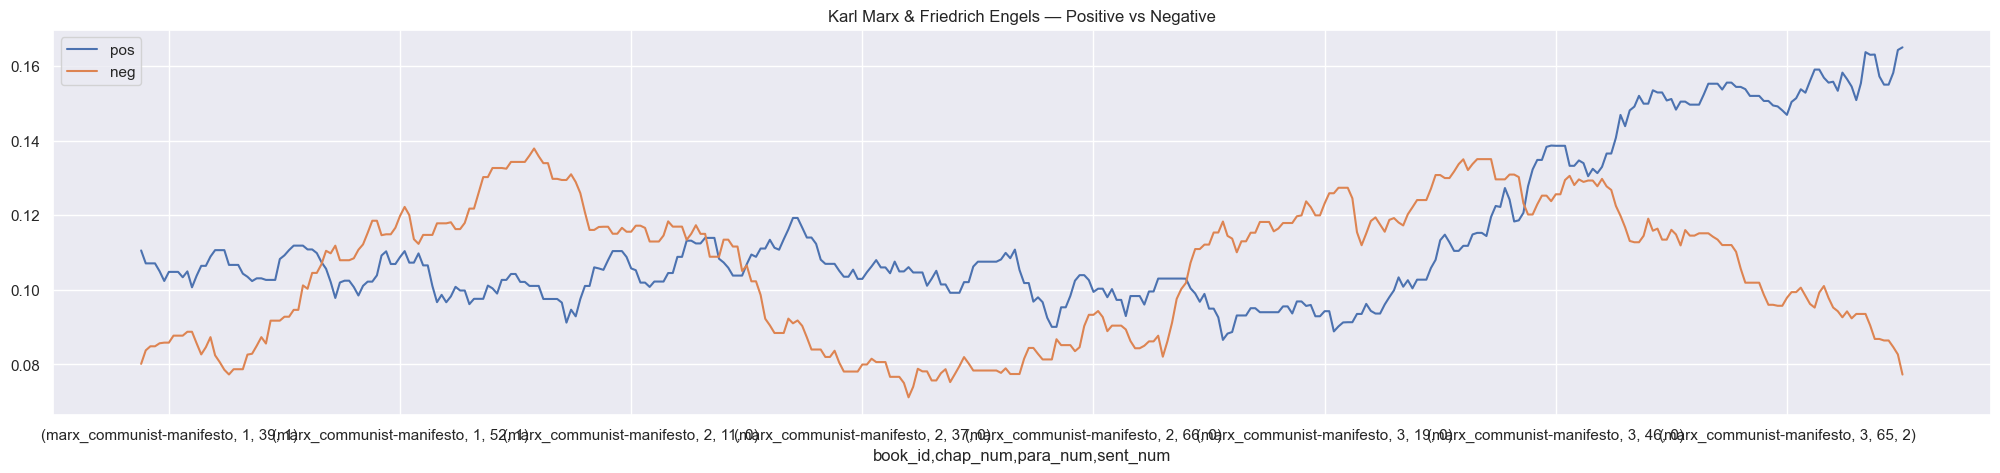

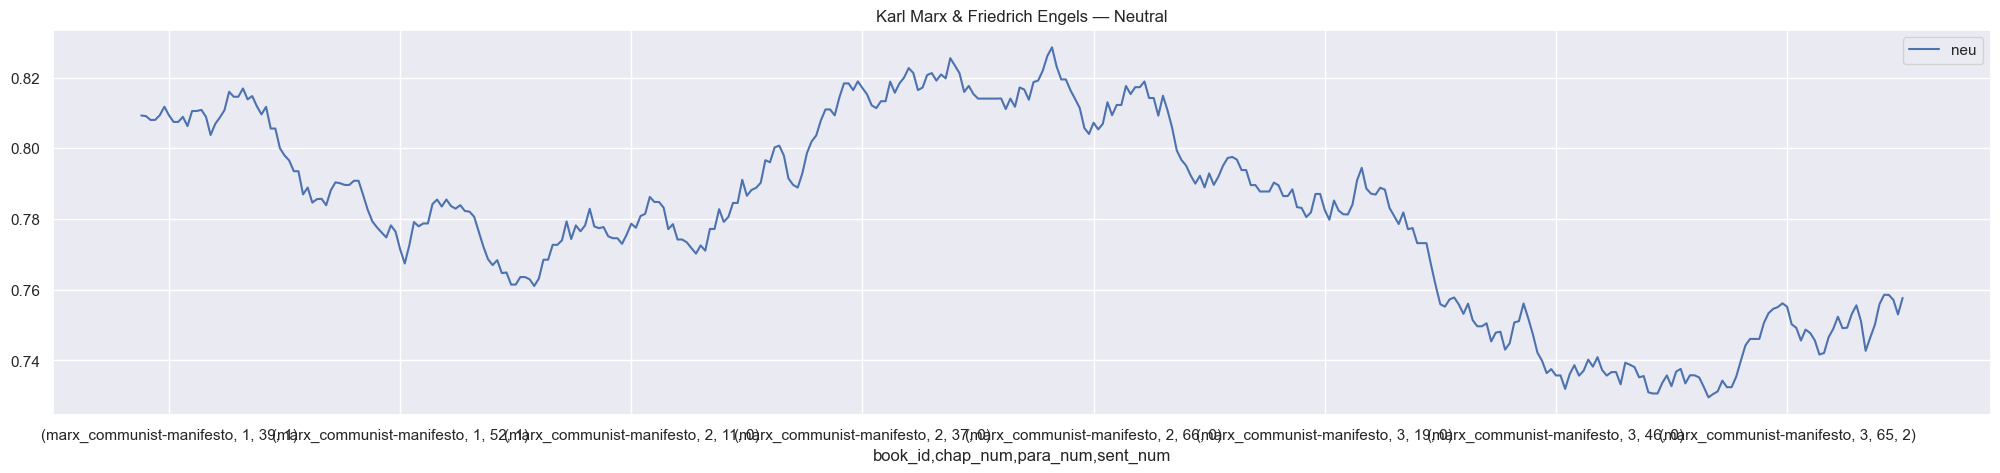

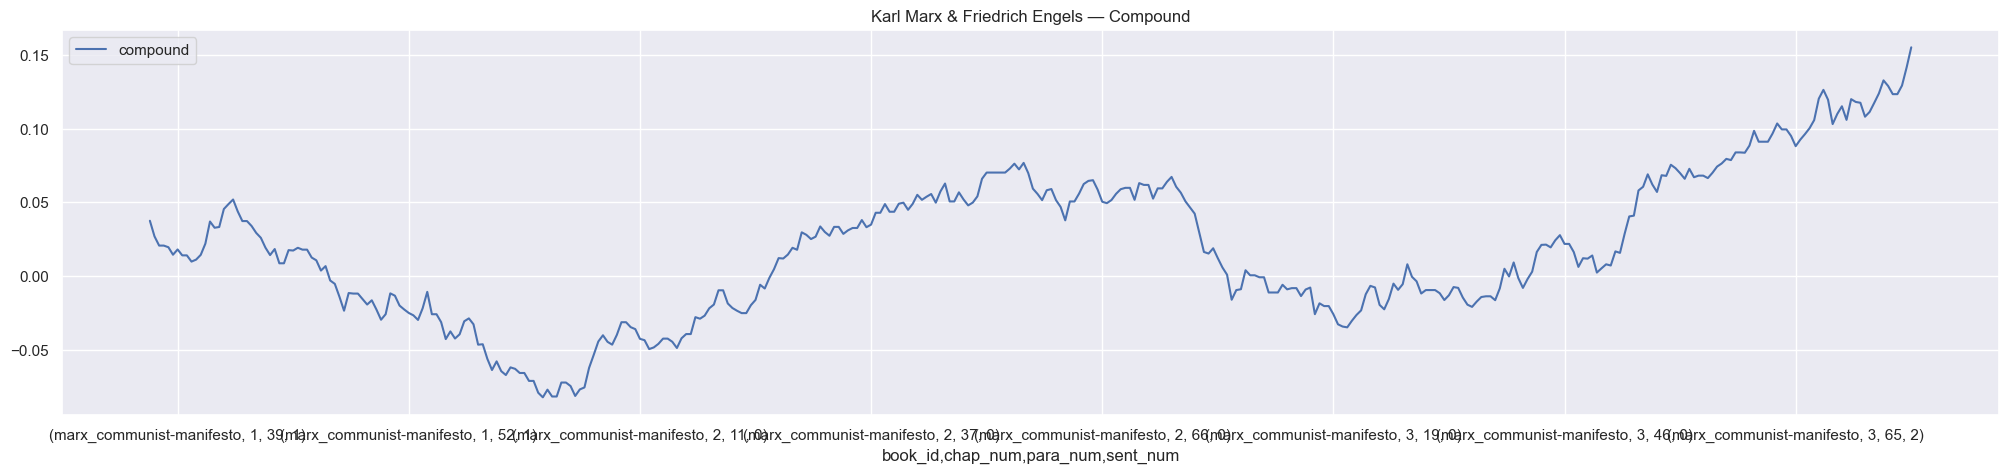


Mao Zedong


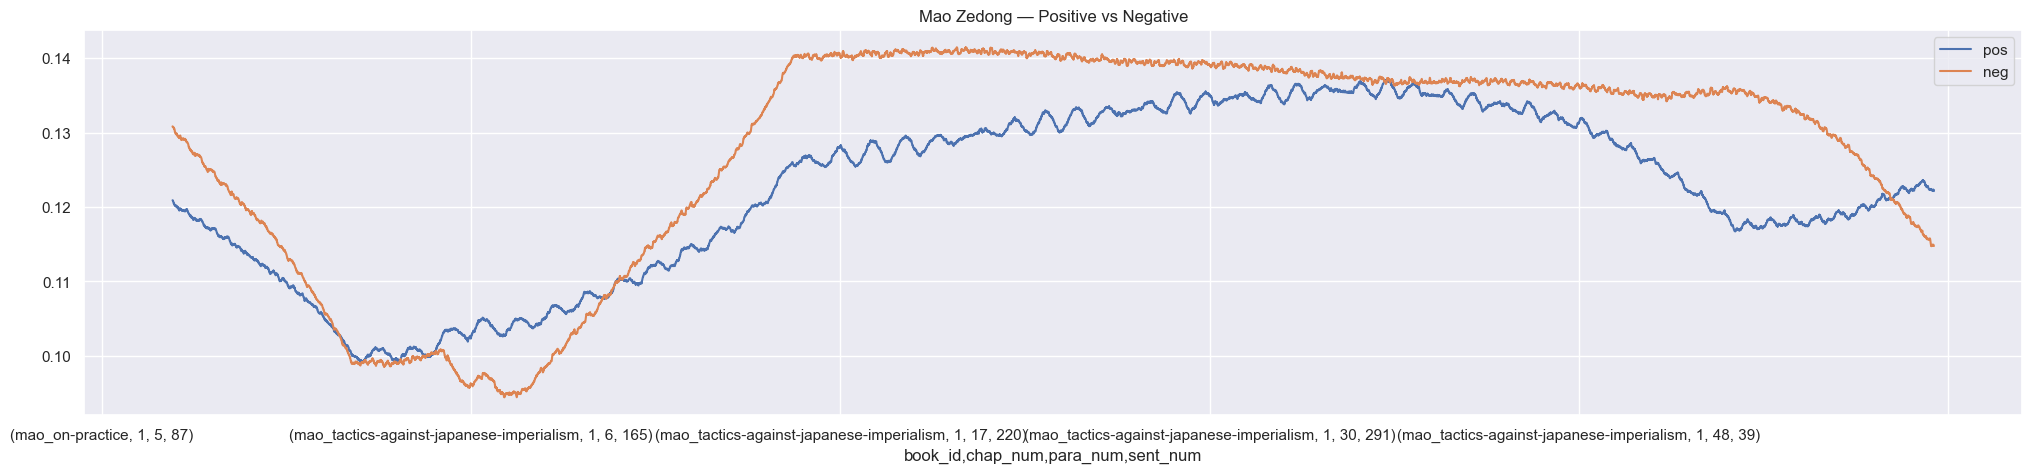

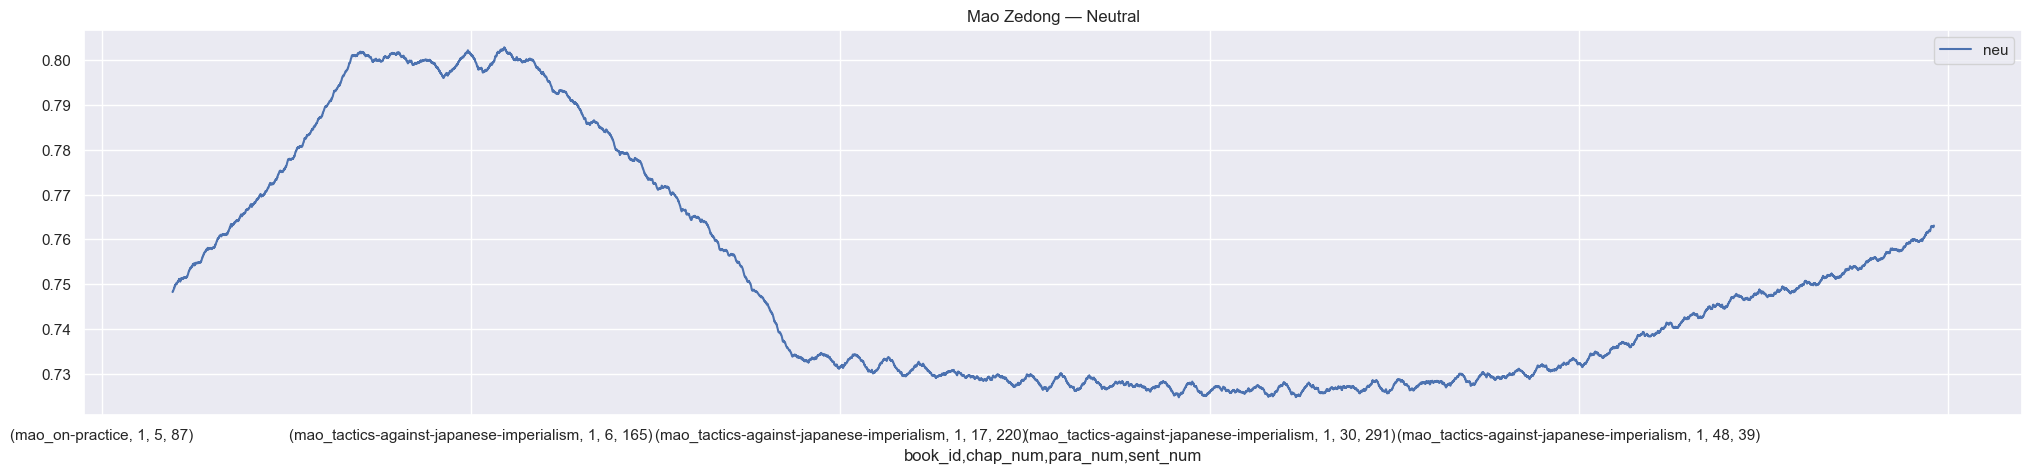

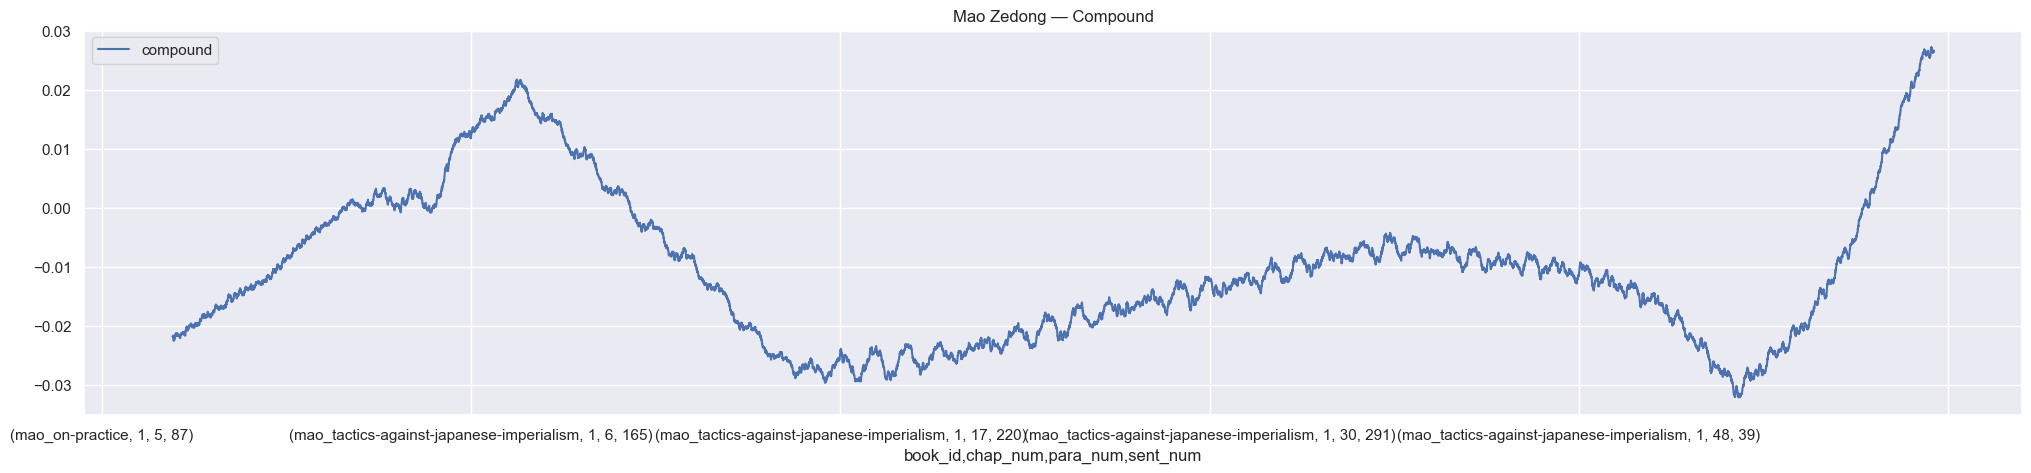


Rosa Luxemburg


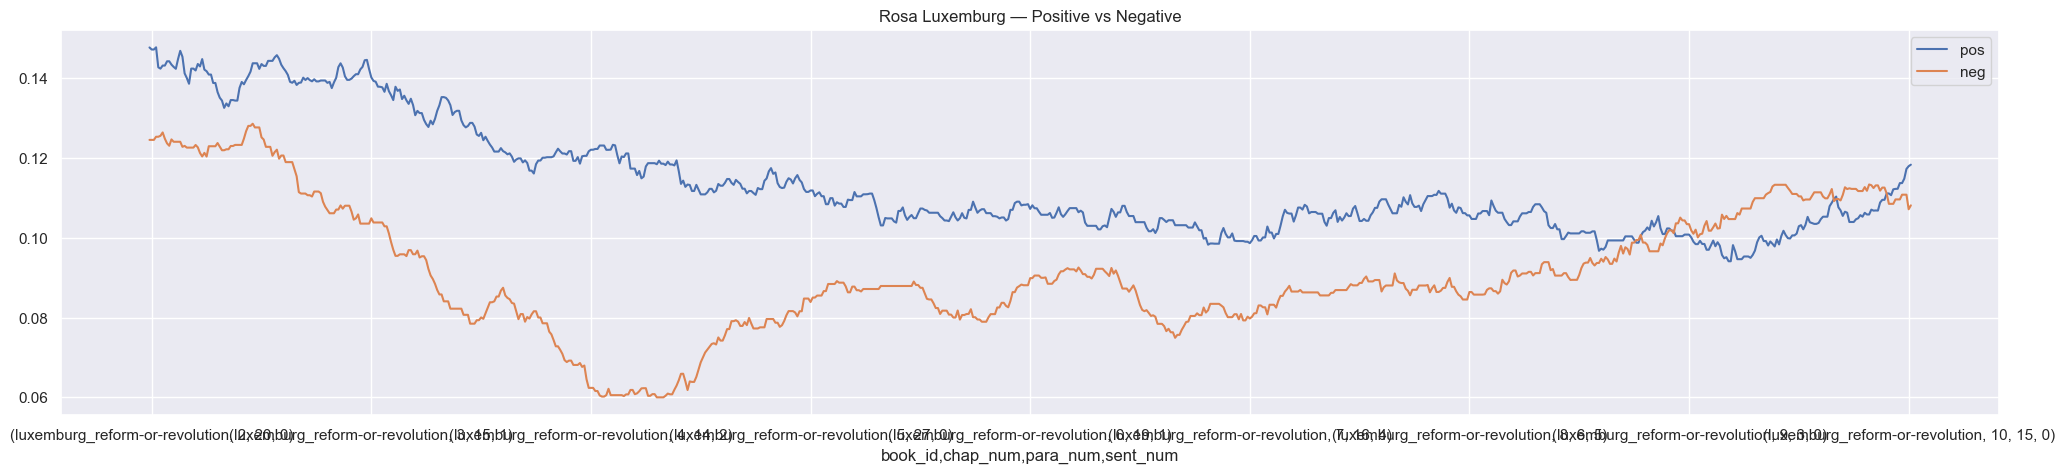

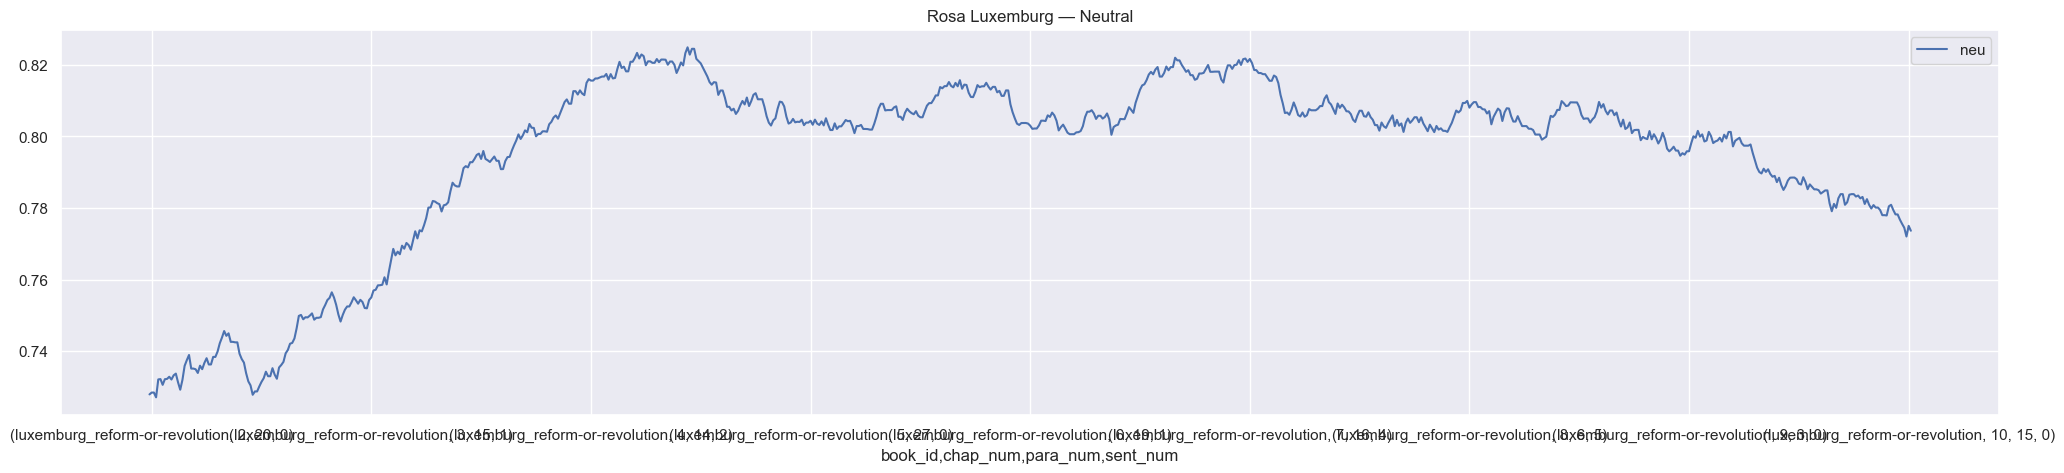

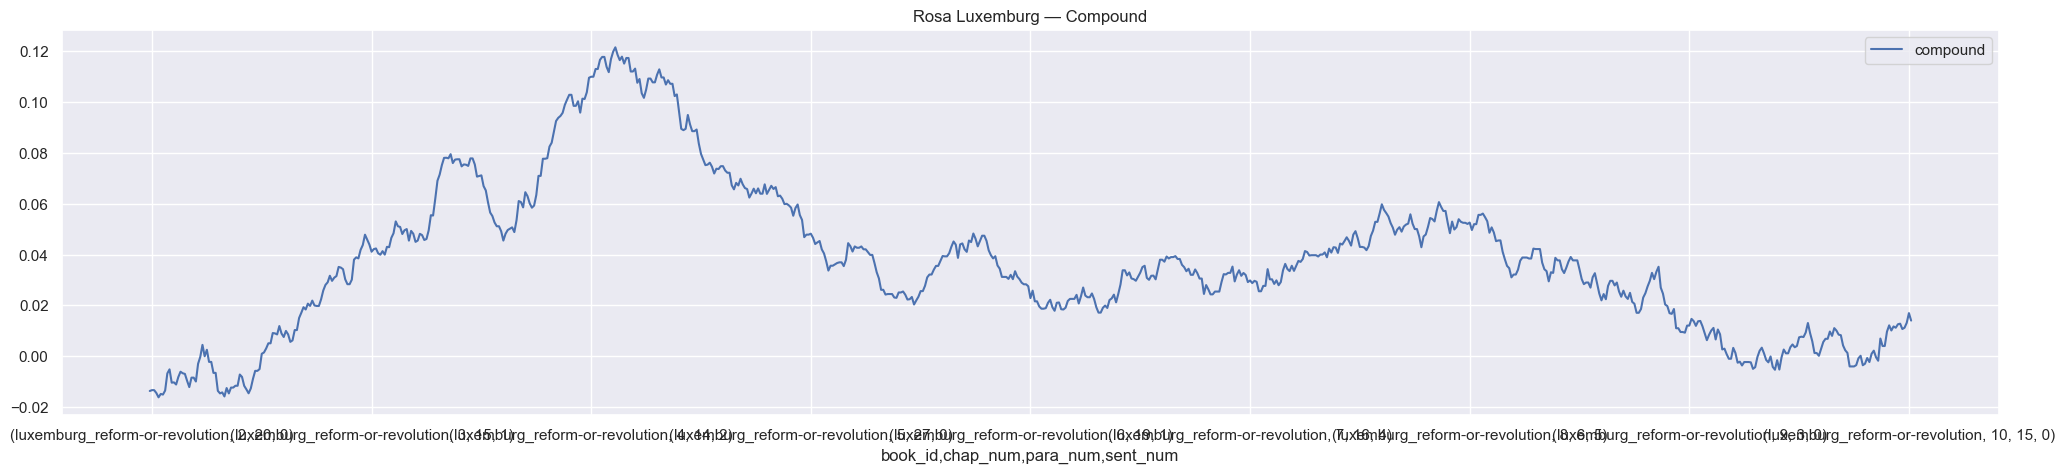

In [13]:
author_vader = SENT_VADER.groupby('author')[vader_cols].mean()
for author, group in SENT_VADER.groupby('author'):
    vader_chap = group[vader_cols]
    w = int(vader_chap.shape[0] / 5)
    
    print(f'\n{author}')
    vader_chap[['pos', 'neg']].rolling(w).mean().plot(figsize=(25, 5), title=f'{author} — Positive vs Negative')
    plt.show()
    
    vader_chap[['neu']].rolling(w).mean().plot(figsize=(25, 5), title=f'{author} — Neutral')
    plt.show()
    
    vader_chap[['compound']].rolling(w).mean().plot(figsize=(25, 5), title=f'{author} — Compound')
    plt.show()

VADER BY CHAPTER

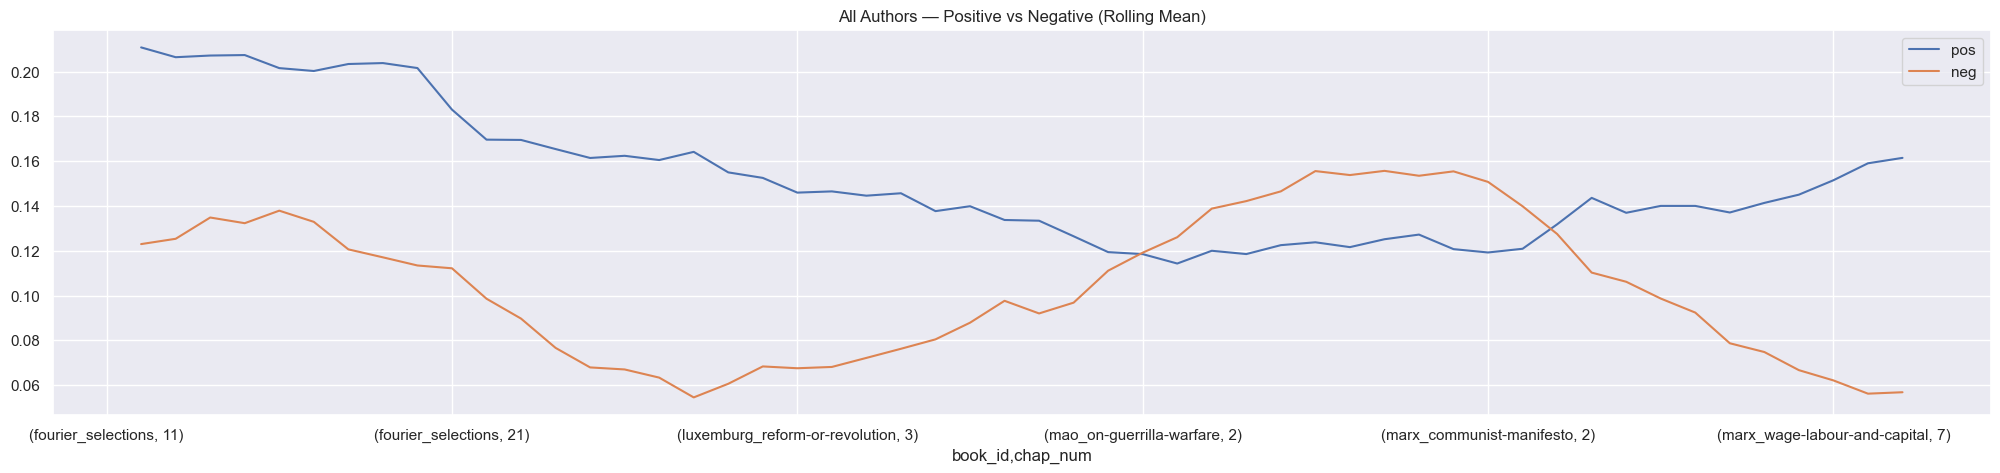

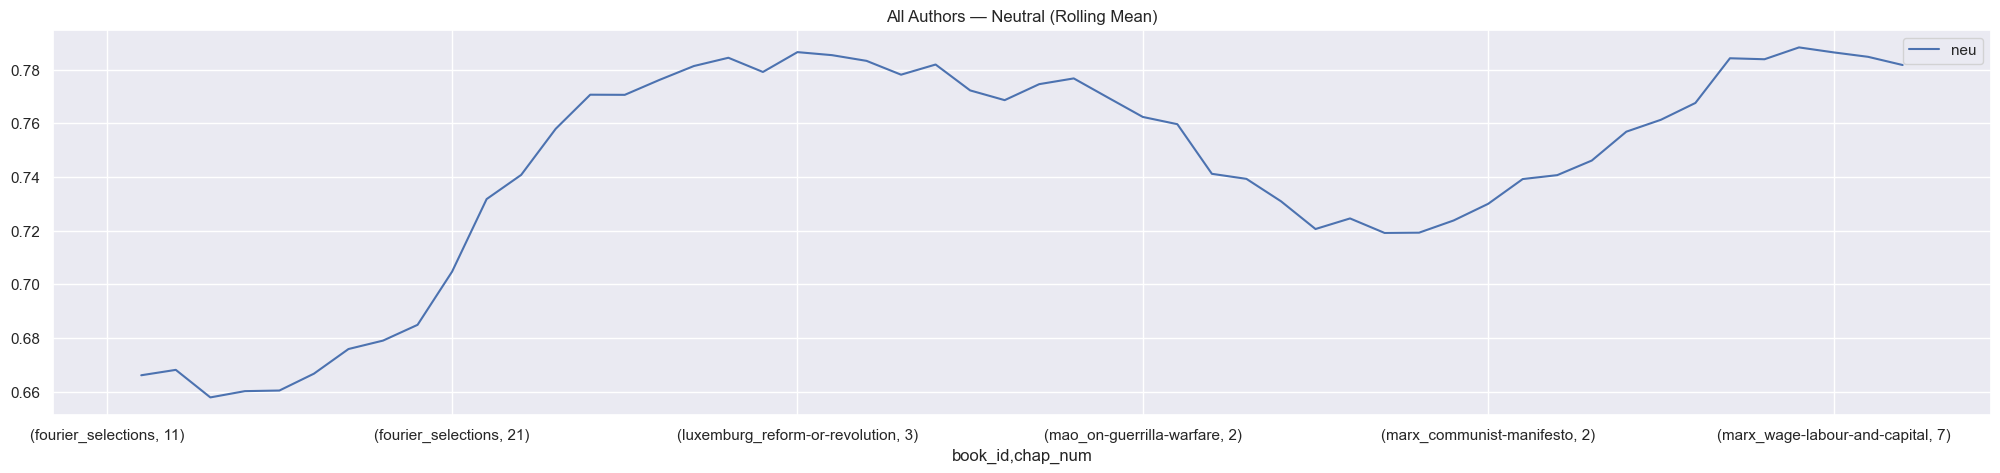

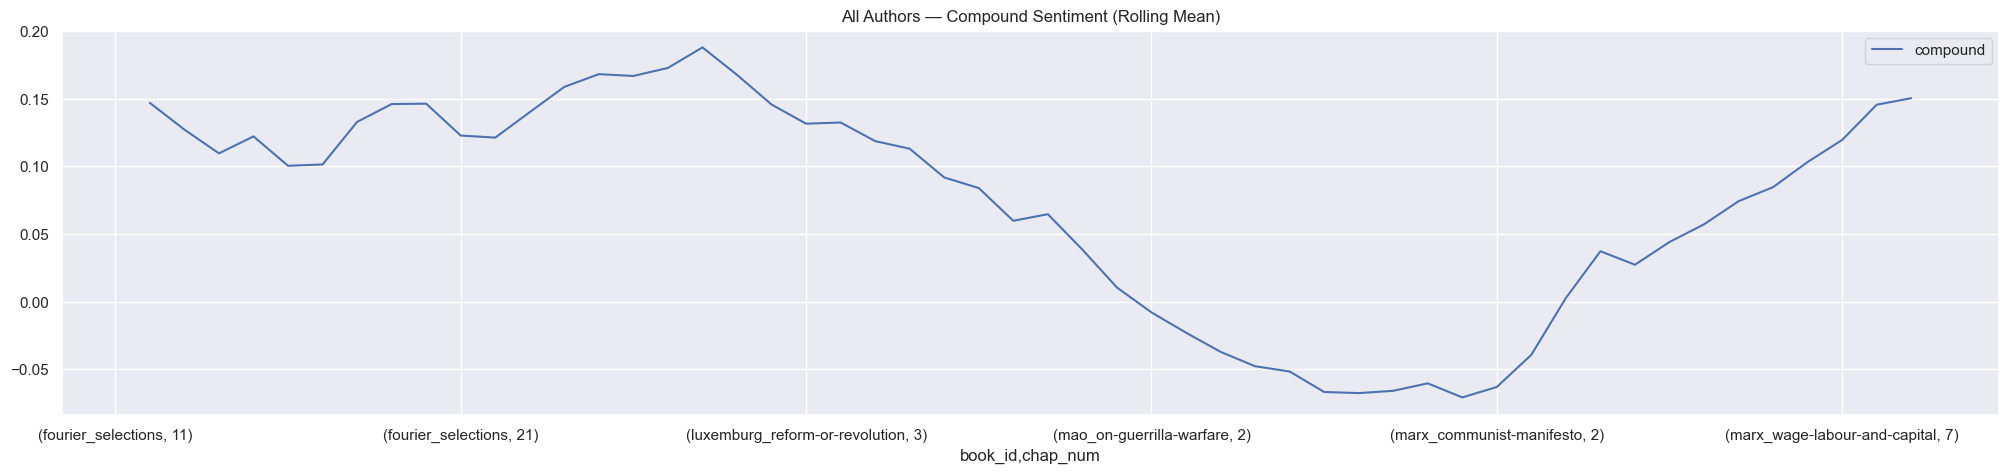

In [14]:
vader_cols = ['pos', 'neg', 'neu', 'compound']
CHAP_VADER = SENT_VADER.groupby(CHAPS)[vader_cols].mean()
CHAP_VADER['author'] = CHAP_VADER.index.get_level_values('book_id').map(AUTHOR_MAP)

w = int(CHAP_VADER.shape[0] / 5)

CHAP_VADER[['pos', 'neg']].rolling(w).mean().plot(figsize=(25, 5), title='All Authors — Positive vs Negative (Rolling Mean)')
plt.show()

CHAP_VADER[['neu']].rolling(w).mean().plot(figsize=(25, 5), title='All Authors — Neutral (Rolling Mean)')
plt.show()

CHAP_VADER[['compound']].rolling(w).mean().plot(figsize=(25, 5), title='All Authors — Compound Sentiment (Rolling Mean)')
plt.show()

In [15]:
# Table 1: Add NRC emotion scores to VOCAB_F5 (shared term_str index)
VOCAB_F5 = pd.read_csv(f5_dir / 'VOCAB_F5.csv', index_col='term_str')
VOCAB_F5 = VOCAB_F5.join(salex.add_prefix('nrc_'), how='left')
VOCAB_F5.to_csv(f5_dir / 'VOCAB_F5.csv')

# Table 2: Document-level sentiment — NRC + VADER per chapter
DOC_SENT = CHAP_SENT.set_index(CHAPS)
DOC_SENT = DOC_SENT.join(CHAP_VADER[vader_cols], how='left')
DOC_SENT.to_csv(f5_dir / 'DOC_SENTIMENT.csv')